# Análisis de Series Temporales
---
Eduardo González Gutiérrez
## Descripción


## Carga de librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [ ]:
# Cargamos los datos
df = pd.read_csv('Series1-6.csv', sep=';', decimal=',')

# Visualizamos las columnas del dataset
print(df.head())
print(df.columns)

## Análisis Serie 1

In [ ]:
# Seleccionamos la Serie 1
serie1 = df['Serie1']

# Visualizamos la serie
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie1, linewidth=1)
ax.set_title('Gráfico de la Serie 1')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show();

In [ ]:
# Convertir a numérico los datos con errores
serie1 = pd.to_numeric(df['Serie1'], errors='coerce')
print("Tipo de los datos {serie1.dtype}")

# Eliminamos los valores Nan de la serie
print(f"NaN en serie1: {serie1.isna().sum()}")
serie1_clean = serie1.dropna()

In [ ]:
# Paso 3 - Test ADF
resultado_adf = adfuller(serie1_clean, maxlag=25)  # 25 lags para Serie 1

print("=== Test ADF - Serie 1 ===")
print(f"Estadístico ADF : {resultado_adf[0]:.4f}")
print(f"p-valor         : {resultado_adf[1]:.4f}")
print(f"Lags usados     : {resultado_adf[2]}")
print(f"Observaciones   : {resultado_adf[3]}")
print("\nValores críticos:")
for nivel, valor in resultado_adf[4].items():
    print(f"  {nivel}: {valor:.4f}")

# Interpretación automática
print("\nInterpretación")
if resultado_adf[1] < 0.05:
    print("p-valor < 0.05, se rechaza H0 y la serie ES estacionaria")
else:
    print("p-valor ≥ 0.05, no se rechaza H0 por lo que la serie NO ES estacionaria. Hay que aplicar transformación para hacerla estacionaria")

In [ ]:
# Normalidad
print("Normalidad - Serie 1")

# Test de Shapiro-Wilk
stat, p_valor = stats.shapiro(serie1_clean)
print(f"Shapiro-Wilk estadístico : {stat:.4f}")
print(f"p-valor                  : {p_valor:.4f}")

# Asimetría y curtosis
print(f"Asimetría (skewness)     : {stats.skew(serie1_clean):.4f}")
print(f"Curtosis (kurtosis)      : {stats.kurtosis(serie1_clean):.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(serie1_clean, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Serie 1 — Histograma')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

# Q-Q Plot
stats.probplot(serie1_clean, dist="norm", plot=axes[1])
axes[1].set_title('Serie 1 — Q-Q Plot')

plt.tight_layout()
plt.show()

# Interpretación
print("\n--- Interpretación ---")
if p_valor < 0.05:
    print("p-valor < 0.05, se rechaza normalidad por lo que la serie NO sigue una distribución normal")
else:
    print("p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal")

In [ ]:
# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie1_clean, lags=25, ax=axes[0])
axes[0].set_title('Serie 1 — ACF')

plot_pacf(serie1_clean, lags=25, ax=axes[1])
axes[1].set_title('Serie 1 — PACF')

plt.tight_layout()
plt.show()

# Test de Ljung-Box
lb = acorr_ljungbox(serie1_clean, lags=25, return_df=True)
print("=== Ljung-Box - Serie 1 ===")
print(lb)

# Interpretación
print("\n--- Interpretación ---")
if (lb['lb_pvalue'] < 0.05).any():
    print("Algún p-valor < 0.05 → Existe autocorrelación significativa → La serie NO es ruido blanco")
else:
    print("Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco")

In [ ]:
serie1_cuadrado = serie1_clean ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie1_cuadrado, lags=25, ax=axes[0])
axes[0].set_title('Serie 1² — ACF')

plot_pacf(serie1_cuadrado, lags=25, ax=axes[1])
axes[1].set_title('Serie 1² — PACF')

plt.tight_layout()
plt.show()

# Ljung-Box sobre la serie al cuadrado
lb_cuadrado = acorr_ljungbox(serie1_cuadrado, lags=25, return_df=True)
print("=== Ljung-Box Serie 1² ===")
print(lb_cuadrado)

print("\n--- Interpretación ---")
if (lb_cuadrado['lb_pvalue'] < 0.05).any():
    print("Hay autocorrelación en la serie al cuadrado → dependencia no lineal → posible modelo ARCH/GARCH")
else:
    print("No hay autocorrelación en la serie al cuadrado → confirma que es SWN (Strong White Noise)")

## Serie 2

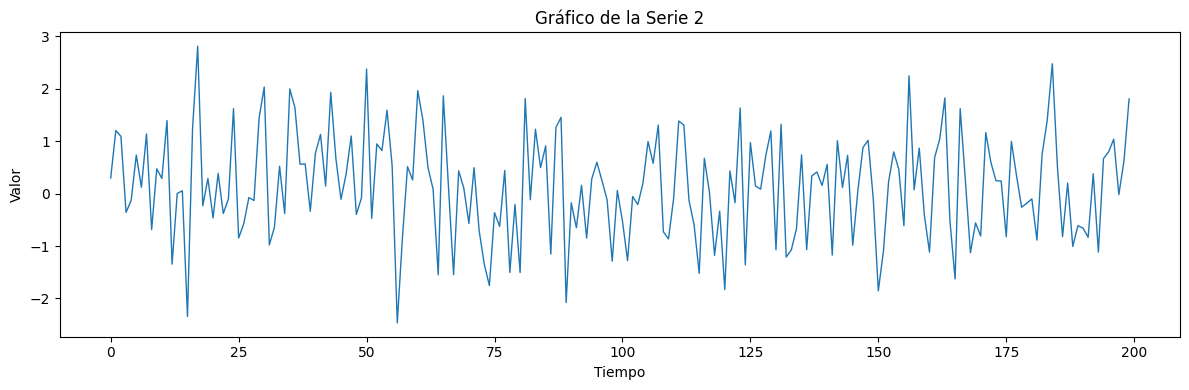

Tipo de los datos {serie2.dtype}
NaN en serie2: 1800
=== Test ADF - Serie 2 ===
Estadístico ADF : -13.6634
p-valor         : 0.0000
Lags usados     : 0
Observaciones   : 199

Valores críticos:
  1%: -3.4636
  5%: -2.8762
  10%: -2.5746

Interpretación
p-valor < 0.05, se rechaza H0 y la serie ES estacionaria
Normalidad - Serie 2
Shapiro-Wilk estadístico : 0.9974
p-valor                  : 0.9866
Asimetría (skewness)     : 0.0048
Curtosis (kurtosis)      : -0.2749


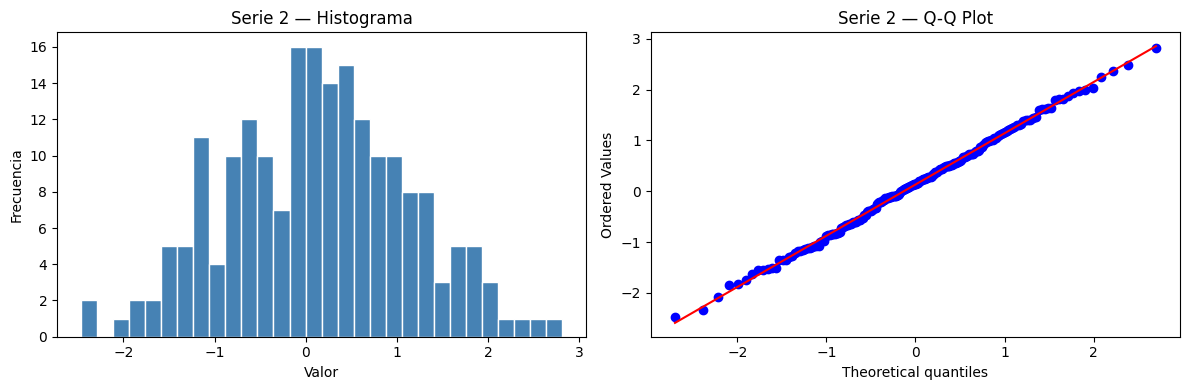


--- Interpretación ---
p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal


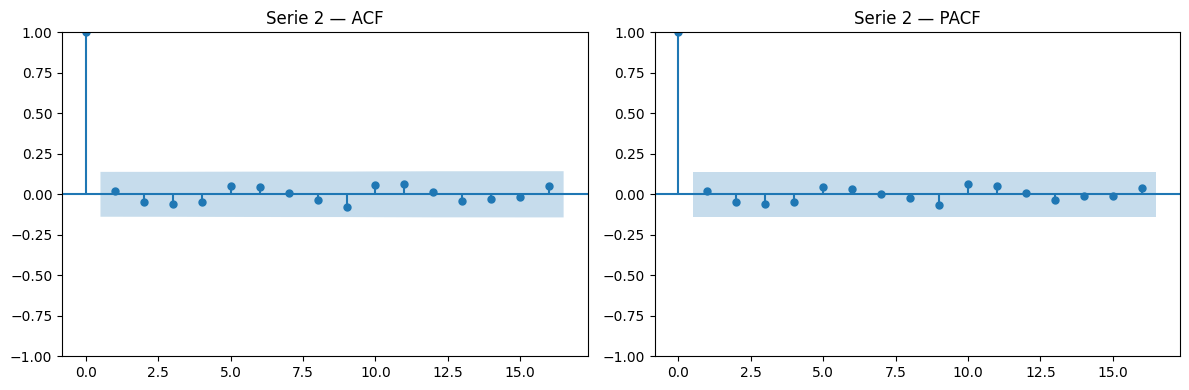

=== Ljung-Box - Serie 2 ===
     lb_stat  lb_pvalue
1   0.077663   0.780489
2   0.527457   0.768182
3   1.284282   0.732869
4   1.696527   0.791348
5   2.186557   0.822775
6   2.587878   0.858506
7   2.593372   0.919903
8   2.811300   0.945635
9   4.083124   0.905857
10  4.824323   0.902600
11  5.718809   0.891452
12  5.772438   0.927116
13  6.111609   0.941996
14  6.320783   0.957747
15  6.376850   0.972699
16  6.925183   0.974676

--- Interpretación ---
Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco


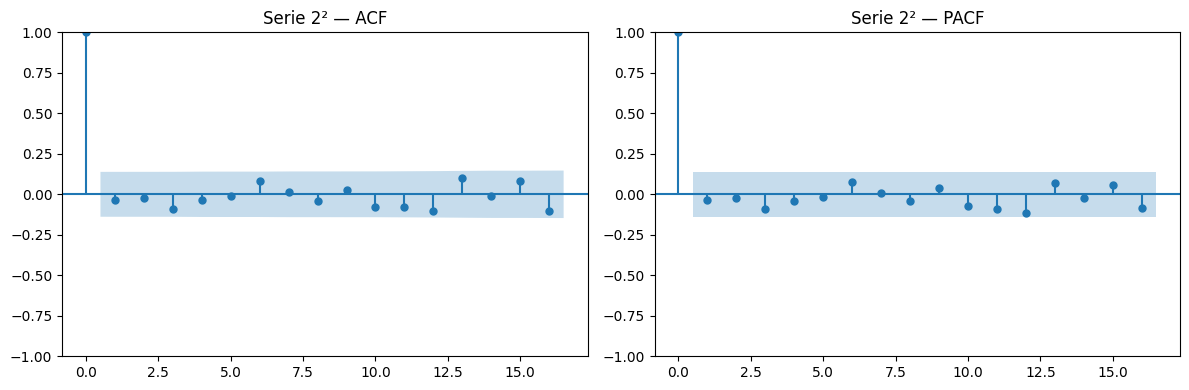

=== Ljung-Box Serie 2² ===
      lb_stat  lb_pvalue
1    0.270347   0.603099
2    0.352867   0.838255
3    2.031818   0.565829
4    2.299284   0.680899
5    2.328156   0.802123
6    3.795061   0.704387
7    3.824407   0.799766
8    4.156717   0.842714
9    4.306387   0.890115
10   5.627523   0.845527
11   7.039502   0.795876
12   9.198722   0.685870
13  11.264945   0.588633
14  11.301245   0.662225
15  12.718527   0.624029
16  15.019527   0.523209

--- Interpretación ---
No hay autocorrelación en la serie al cuadrado → confirma que es SWN (Strong White Noise)


In [13]:
# Seleccionamos la Serie 2
serie2 = df['Serie2']

# Visualizamos la serie
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie2, linewidth=1)
ax.set_title('Gráfico de la Serie 2')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show();

# Convertir a numérico los datos con errores
serie2 = pd.to_numeric(df['Serie2'], errors='coerce')
print("Tipo de los datos {serie2.dtype}")

# Eliminamos los valores Nan de la serie
print(f"NaN en serie2: {serie2.isna().sum()}")
serie2_clean = serie2.dropna()

# Paso 3 - Test ADF
resultado_adf2 = adfuller(serie2_clean, maxlag=16)  # 16 lags para Serie 2

print("=== Test ADF - Serie 2 ===")
print(f"Estadístico ADF : {resultado_adf2[0]:.4f}")
print(f"p-valor         : {resultado_adf2[1]:.4f}")
print(f"Lags usados     : {resultado_adf2[2]}")
print(f"Observaciones   : {resultado_adf2[3]}")
print("\nValores críticos:")
for nivel, valor in resultado_adf2[4].items():
    print(f"  {nivel}: {valor:.4f}")

# Interpretación automática
print("\nInterpretación")
if resultado_adf2[1] < 0.05:
    print("p-valor < 0.05, se rechaza H0 y la serie ES estacionaria")
else:
    print("p-valor ≥ 0.05, no se rechaza H0 por lo que la serie NO ES estacionaria. Hay que aplicar transformación para hacerla estacionaria")


# Normalidad
print("Normalidad - Serie 2")

# Test de Shapiro-Wilk
stat2, p_valor2 = stats.shapiro(serie2_clean)
print(f"Shapiro-Wilk estadístico : {stat2:.4f}")
print(f"p-valor                  : {p_valor2:.4f}")

# Asimetría y curtosis
print(f"Asimetría (skewness)     : {stats.skew(serie2_clean):.4f}")
print(f"Curtosis (kurtosis)      : {stats.kurtosis(serie2_clean):.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(serie2_clean, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Serie 2 — Histograma')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

# Q-Q Plot
stats.probplot(serie2_clean, dist="norm", plot=axes[1])
axes[1].set_title('Serie 2 — Q-Q Plot')

plt.tight_layout()
plt.show()

# Interpretación
print("\n--- Interpretación ---")
if p_valor2 < 0.05:
    print("p-valor < 0.05, se rechaza normalidad por lo que la serie NO sigue una distribución normal")
else:
    print("p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal")


# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie2_clean, lags=16, ax=axes[0])
axes[0].set_title('Serie 2 — ACF')

plot_pacf(serie2_clean, lags=16, ax=axes[1])
axes[1].set_title('Serie 2 — PACF')

plt.tight_layout()
plt.show()

# Test de Ljung-Box
lb2 = acorr_ljungbox(serie2_clean, lags=16, return_df=True)
print("=== Ljung-Box - Serie 2 ===")
print(lb2)

# Interpretación
print("\n--- Interpretación ---")
if (lb2['lb_pvalue'] < 0.05).any():
    print("Algún p-valor < 0.05 → Existe autocorrelación significativa → La serie NO es ruido blanco")
else:
    print("Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco")


# Serie al cuadrado
serie2_cuadrado = serie2_clean ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie2_cuadrado, lags=16, ax=axes[0])
axes[0].set_title('Serie 2² — ACF')

plot_pacf(serie2_cuadrado, lags=16, ax=axes[1])
axes[1].set_title('Serie 2² — PACF')

plt.tight_layout()
plt.show()

# Ljung-Box sobre la serie al cuadrado
lb2_cuadrado = acorr_ljungbox(serie2_cuadrado, lags=16, return_df=True)
print("=== Ljung-Box Serie 2² ===")
print(lb2_cuadrado)

print("\n--- Interpretación ---")
if (lb2_cuadrado['lb_pvalue'] < 0.05).any():
    print("Hay autocorrelación en la serie al cuadrado → dependencia no lineal → posible modelo ARCH/GARCH")
else:
    print("No hay autocorrelación en la serie al cuadrado → confirma que es SWN (Strong White Noise)")

## Serie 3

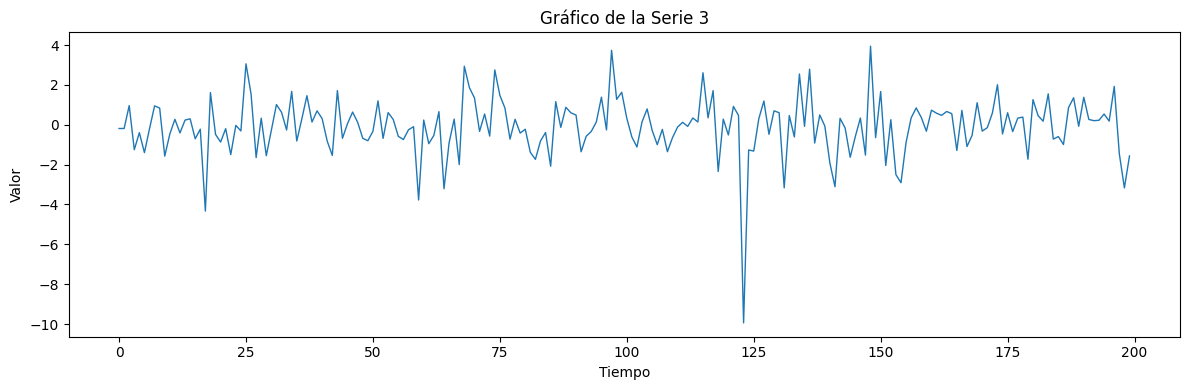

Tipo de los datos {serie3.dtype}
NaN en serie3: 1800
=== Test ADF - Serie 3 ===
Estadístico ADF : -8.5065
p-valor         : 0.0000
Lags usados     : 1
Observaciones   : 198

Valores críticos:
  1%: -3.4638
  5%: -2.8763
  10%: -2.5746

Interpretación
p-valor < 0.05, se rechaza H0 y la serie ES estacionaria
Normalidad - Serie 3
Shapiro-Wilk estadístico : 0.8940
p-valor                  : 0.0000
Asimetría (skewness)     : -1.5797
Curtosis (kurtosis)      : 10.3025


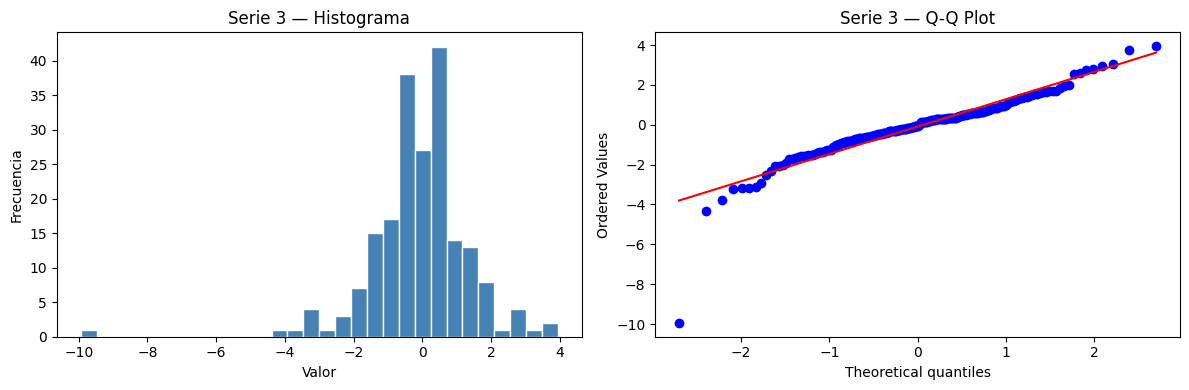


--- Interpretación ---
p-valor < 0.05, se rechaza normalidad por lo que la serie NO sigue una distribución normal


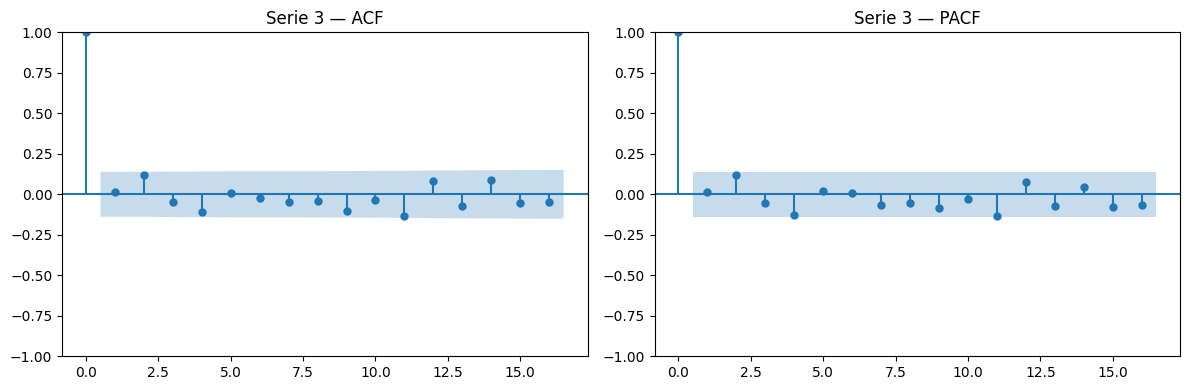

=== Ljung-Box - Serie 3 ===
      lb_stat  lb_pvalue
1    0.059940   0.806591
2    3.034062   0.219362
3    3.549251   0.314430
4    6.142869   0.188730
5    6.149371   0.291955
6    6.244047   0.396415
7    6.722309   0.458354
8    7.086812   0.527296
9    9.324888   0.407841
10   9.600340   0.476228
11  13.605470   0.255598
12  15.095595   0.236250
13  16.287599   0.233948
14  17.961474   0.208541
15  18.657129   0.229694
16  19.182391   0.259319

--- Interpretación ---
Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco


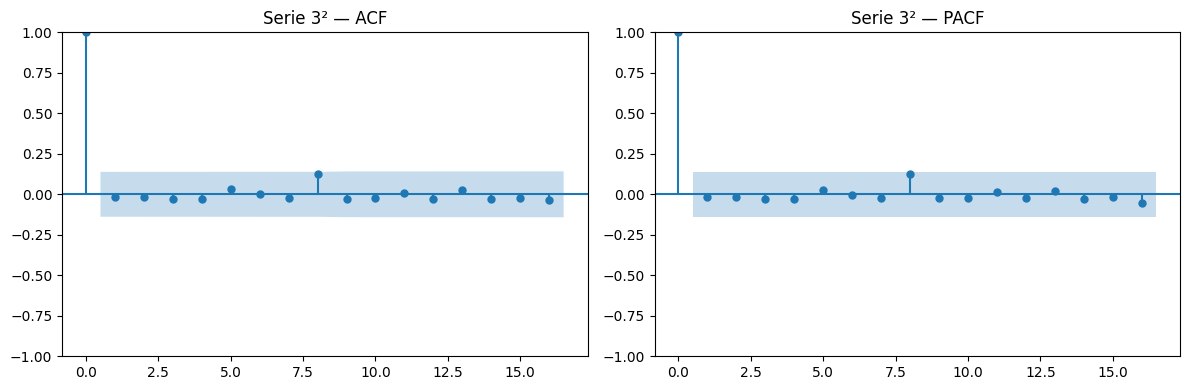

=== Ljung-Box Serie 3² ===
     lb_stat  lb_pvalue
1   0.057617   0.810304
2   0.103212   0.949703
3   0.275363   0.964593
4   0.422699   0.980577
5   0.621089   0.987017
6   0.621388   0.996033
7   0.736352   0.998041
8   3.933450   0.863077
9   4.119789   0.903353
10  4.212616   0.937246
11  4.233039   0.962597
12  4.431992   0.974321
13  4.620900   0.982619
14  4.782063   0.988620
15  4.901177   0.992931
16  5.163180   0.994881

--- Interpretación ---
No hay autocorrelación en la serie al cuadrado → confirma que es SWN (Strong White Noise)


In [14]:
# Seleccionamos la Serie 3
serie3 = df['Serie3']

# Visualizamos la serie
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie3, linewidth=1)
ax.set_title('Gráfico de la Serie 3')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show();

# Convertir a numérico los datos con errores
serie3 = pd.to_numeric(df['Serie3'], errors='coerce')
print("Tipo de los datos {serie3.dtype}")

# Eliminamos los valores Nan de la serie
print(f"NaN en serie3: {serie3.isna().sum()}")
serie3_clean = serie3.dropna()

# Paso 3 - Test ADF
resultado_adf3 = adfuller(serie3_clean, maxlag=16)  # 16 lags para Serie 3

print("=== Test ADF - Serie 3 ===")
print(f"Estadístico ADF : {resultado_adf3[0]:.4f}")
print(f"p-valor         : {resultado_adf3[1]:.4f}")
print(f"Lags usados     : {resultado_adf3[2]}")
print(f"Observaciones   : {resultado_adf3[3]}")
print("\nValores críticos:")
for nivel, valor in resultado_adf3[4].items():
    print(f"  {nivel}: {valor:.4f}")

# Interpretación automática
print("\nInterpretación")
if resultado_adf3[1] < 0.05:
    print("p-valor < 0.05, se rechaza H0 y la serie ES estacionaria")
else:
    print("p-valor ≥ 0.05, no se rechaza H0 por lo que la serie NO ES estacionaria. Hay que aplicar transformación para hacerla estacionaria")


# Normalidad
print("Normalidad - Serie 3")

# Test de Shapiro-Wilk
stat3, p_valor3 = stats.shapiro(serie3_clean)
print(f"Shapiro-Wilk estadístico : {stat3:.4f}")
print(f"p-valor                  : {p_valor3:.4f}")

# Asimetría y curtosis
print(f"Asimetría (skewness)     : {stats.skew(serie3_clean):.4f}")
print(f"Curtosis (kurtosis)      : {stats.kurtosis(serie3_clean):.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(serie3_clean, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Serie 3 — Histograma')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

# Q-Q Plot
stats.probplot(serie3_clean, dist="norm", plot=axes[1])
axes[1].set_title('Serie 3 — Q-Q Plot')

plt.tight_layout()
plt.show()

# Interpretación
print("\n--- Interpretación ---")
if p_valor3 < 0.05:
    print("p-valor < 0.05, se rechaza normalidad por lo que la serie NO sigue una distribución normal")
else:
    print("p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal")


# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie3_clean, lags=16, ax=axes[0])
axes[0].set_title('Serie 3 — ACF')

plot_pacf(serie3_clean, lags=16, ax=axes[1])
axes[1].set_title('Serie 3 — PACF')

plt.tight_layout()
plt.show()

# Test de Ljung-Box
lb3 = acorr_ljungbox(serie3_clean, lags=16, return_df=True)
print("=== Ljung-Box - Serie 3 ===")
print(lb3)

# Interpretación
print("\n--- Interpretación ---")
if (lb3['lb_pvalue'] < 0.05).any():
    print("Algún p-valor < 0.05 → Existe autocorrelación significativa → La serie NO es ruido blanco")
else:
    print("Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco")


# Serie al cuadrado
serie3_cuadrado = serie3_clean ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie3_cuadrado, lags=16, ax=axes[0])
axes[0].set_title('Serie 3² — ACF')

plot_pacf(serie3_cuadrado, lags=16, ax=axes[1])
axes[1].set_title('Serie 3² — PACF')

plt.tight_layout()
plt.show()

# Ljung-Box sobre la serie al cuadrado
lb3_cuadrado = acorr_ljungbox(serie3_cuadrado, lags=16, return_df=True)
print("=== Ljung-Box Serie 3² ===")
print(lb3_cuadrado)

print("\n--- Interpretación ---")
if (lb3_cuadrado['lb_pvalue'] < 0.05).any():
    print("Hay autocorrelación en la serie al cuadrado → dependencia no lineal → posible modelo ARCH/GARCH")
else:
    print("No hay autocorrelación en la serie al cuadrado → confirma que es SWN (Strong White Noise)")

## Serie 4

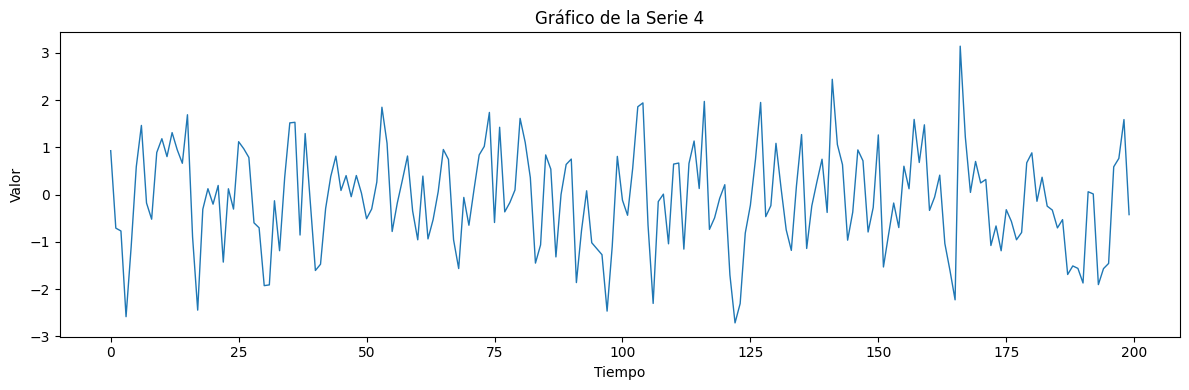

Tipo de los datos {serie4.dtype}
NaN en serie4: 1800
=== Test ADF - Serie 4 ===
Estadístico ADF : -9.3426
p-valor         : 0.0000
Lags usados     : 1
Observaciones   : 198

Valores críticos:
  1%: -3.4638
  5%: -2.8763
  10%: -2.5746

Interpretación
p-valor < 0.05, se rechaza H0 y la serie ES estacionaria
Normalidad - Serie 4
Shapiro-Wilk estadístico : 0.9960
p-valor                  : 0.8851
Asimetría (skewness)     : -0.0366
Curtosis (kurtosis)      : -0.2070


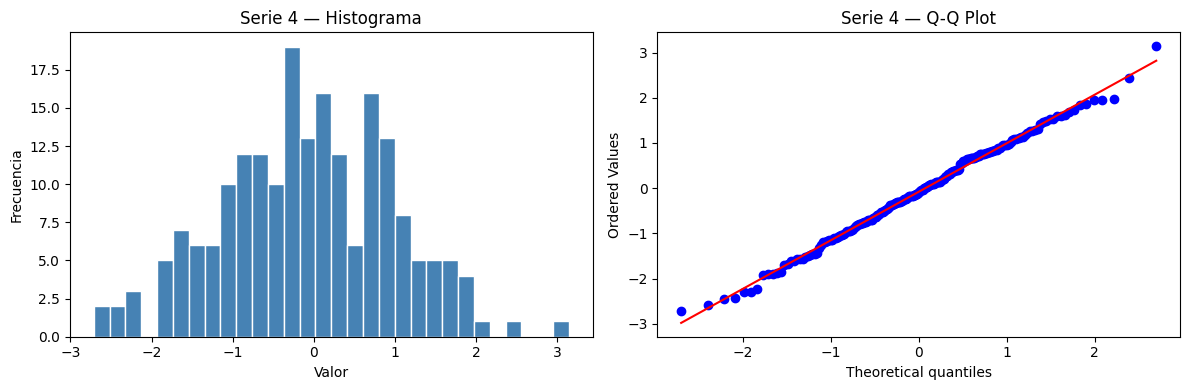


--- Interpretación ---
p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal


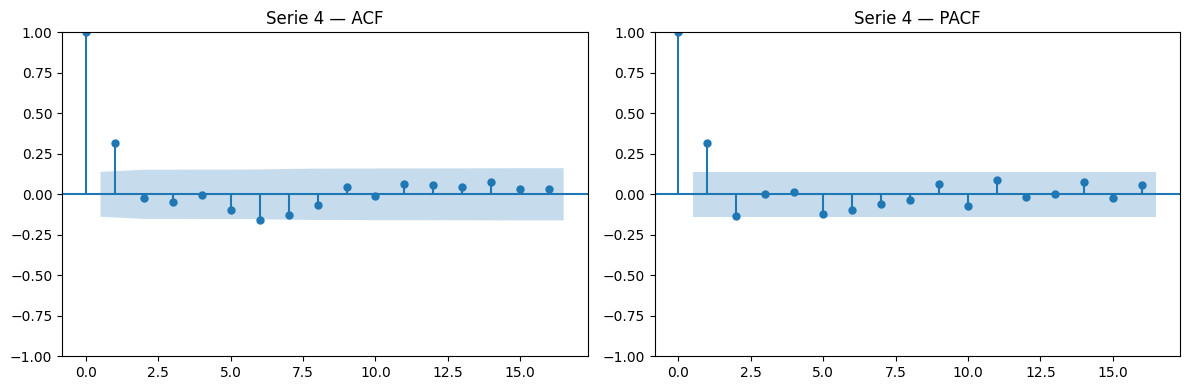

=== Ljung-Box - Serie 4 ===
      lb_stat  lb_pvalue
1   20.337121   0.000006
2   20.418136   0.000037
3   20.896450   0.000111
4   20.898463   0.000332
5   22.949333   0.000345
6   28.387275   0.000079
7   31.900298   0.000042
8   32.802178   0.000067
9   33.181731   0.000124
10  33.209777   0.000251
11  34.041613   0.000356
12  34.785344   0.000507
13  35.209159   0.000786
14  36.388597   0.000912
15  36.594810   0.001450
16  36.859315   0.002195

--- Interpretación ---
Algún p-valor < 0.05 → Existe autocorrelación significativa → La serie NO es ruido blanco


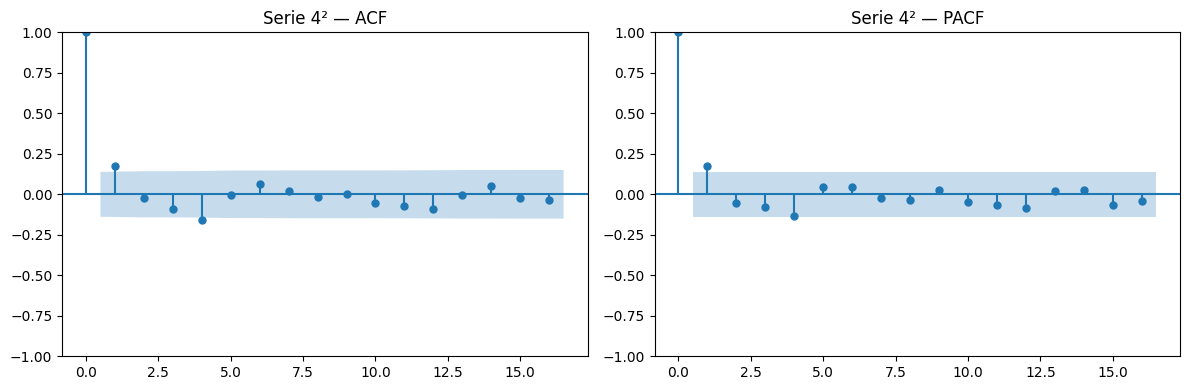

=== Ljung-Box Serie 4² ===
      lb_stat  lb_pvalue
1    5.992241   0.014369
2    6.100619   0.047344
3    7.797327   0.050391
4   12.794142   0.012327
5   12.794783   0.025380
6   13.711654   0.033028
7   13.798212   0.054889
8   13.853961   0.085652
9   13.854723   0.127588
10  14.500273   0.151371
11  15.661581   0.154167
12  17.434068   0.133986
13  17.439633   0.179978
14  17.999327   0.206811
15  18.085483   0.258198
16  18.347182   0.303962

--- Interpretación ---
Hay autocorrelación en la serie al cuadrado → dependencia no lineal → posible modelo ARCH/GARCH


In [15]:
# Seleccionamos la Serie 4
serie4 = df['Serie4']

# Visualizamos la serie
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie4, linewidth=1)
ax.set_title('Gráfico de la Serie 4')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show();

# Convertir a numérico los datos con errores
serie4 = pd.to_numeric(df['Serie4'], errors='coerce')
print("Tipo de los datos {serie4.dtype}")

# Eliminamos los valores Nan de la serie
print(f"NaN en serie4: {serie4.isna().sum()}")
serie4_clean = serie4.dropna()

# Paso 3 - Test ADF
resultado_adf4 = adfuller(serie4_clean, maxlag=16)  # 16 lags para Serie 4

print("=== Test ADF - Serie 4 ===")
print(f"Estadístico ADF : {resultado_adf4[0]:.4f}")
print(f"p-valor         : {resultado_adf4[1]:.4f}")
print(f"Lags usados     : {resultado_adf4[2]}")
print(f"Observaciones   : {resultado_adf4[3]}")
print("\nValores críticos:")
for nivel, valor in resultado_adf4[4].items():
    print(f"  {nivel}: {valor:.4f}")

# Interpretación automática
print("\nInterpretación")
if resultado_adf4[1] < 0.05:
    print("p-valor < 0.05, se rechaza H0 y la serie ES estacionaria")
else:
    print("p-valor ≥ 0.05, no se rechaza H0 por lo que la serie NO ES estacionaria. Hay que aplicar transformación para hacerla estacionaria")


# Normalidad
print("Normalidad - Serie 4")

# Test de Shapiro-Wilk
stat4, p_valor4 = stats.shapiro(serie4_clean)
print(f"Shapiro-Wilk estadístico : {stat4:.4f}")
print(f"p-valor                  : {p_valor4:.4f}")

# Asimetría y curtosis
print(f"Asimetría (skewness)     : {stats.skew(serie4_clean):.4f}")
print(f"Curtosis (kurtosis)      : {stats.kurtosis(serie4_clean):.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(serie4_clean, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Serie 4 — Histograma')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

# Q-Q Plot
stats.probplot(serie4_clean, dist="norm", plot=axes[1])
axes[1].set_title('Serie 4 — Q-Q Plot')

plt.tight_layout()
plt.show()

# Interpretación
print("\n--- Interpretación ---")
if p_valor4 < 0.05:
    print("p-valor < 0.05, se rechaza normalidad por lo que la serie NO sigue una distribución normal")
else:
    print("p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal")


# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie4_clean, lags=16, ax=axes[0])
axes[0].set_title('Serie 4 — ACF')

plot_pacf(serie4_clean, lags=16, ax=axes[1])
axes[1].set_title('Serie 4 — PACF')

plt.tight_layout()
plt.show()

# Test de Ljung-Box
lb4 = acorr_ljungbox(serie4_clean, lags=16, return_df=True)
print("=== Ljung-Box - Serie 4 ===")
print(lb4)

# Interpretación
print("\n--- Interpretación ---")
if (lb4['lb_pvalue'] < 0.05).any():
    print("Algún p-valor < 0.05 → Existe autocorrelación significativa → La serie NO es ruido blanco")
else:
    print("Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco")


# Serie al cuadrado
serie4_cuadrado = serie4_clean ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie4_cuadrado, lags=16, ax=axes[0])
axes[0].set_title('Serie 4² — ACF')

plot_pacf(serie4_cuadrado, lags=16, ax=axes[1])
axes[1].set_title('Serie 4² — PACF')

plt.tight_layout()
plt.show()

# Ljung-Box sobre la serie al cuadrado
lb4_cuadrado = acorr_ljungbox(serie4_cuadrado, lags=16, return_df=True)
print("=== Ljung-Box Serie 4² ===")
print(lb4_cuadrado)

print("\n--- Interpretación ---")
if (lb4_cuadrado['lb_pvalue'] < 0.05).any():
    print("Hay autocorrelación en la serie al cuadrado → dependencia no lineal → posible modelo ARCH/GARCH")
else:
    print("No hay autocorrelación en la serie al cuadrado → confirma que es SWN (Strong White Noise)")

## Serie 5

In [ ]:
# Seleccionamos la Serie 5
serie5 = df['Serie5']

# Visualizamos la serie
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie5, linewidth=1)
ax.set_title('Gráfico de la Serie 5')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show();

# Convertir a numérico los datos con errores
serie5 = pd.to_numeric(df['Serie5'], errors='coerce')
print("Tipo de los datos {serie5.dtype}")

# Eliminamos los valores Nan de la serie
print(f"NaN en serie5: {serie5.isna().sum()}")
serie5_clean = serie5.dropna()

# Paso 3 - Test ADF
resultado_adf5 = adfuller(serie5_clean, maxlag=16)  # 16 lags para Serie 5

print("=== Test ADF - Serie 5 ===")
print(f"Estadístico ADF : {resultado_adf5[0]:.4f}")
print(f"p-valor         : {resultado_adf5[1]:.4f}")
print(f"Lags usados     : {resultado_adf5[2]}")
print(f"Observaciones   : {resultado_adf5[3]}")
print("\nValores críticos:")
for nivel, valor in resultado_adf5[4].items():
    print(f"  {nivel}: {valor:.4f}")

# Interpretación automática
print("\nInterpretación")
if resultado_adf5[1] < 0.05:
    print("p-valor < 0.05, se rechaza H0 y la serie ES estacionaria")
else:
    print("p-valor ≥ 0.05, no se rechaza H0 por lo que la serie NO ES estacionaria. Hay que aplicar transformación para hacerla estacionaria")


# Normalidad
print("Normalidad - Serie 5")

# Test de Shapiro-Wilk
stat5, p_valor5 = stats.shapiro(serie5_clean)
print(f"Shapiro-Wilk estadístico : {stat5:.4f}")
print(f"p-valor                  : {p_valor5:.4f}")

# Asimetría y curtosis
print(f"Asimetría (skewness)     : {stats.skew(serie5_clean):.4f}")
print(f"Curtosis (kurtosis)      : {stats.kurtosis(serie5_clean):.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(serie5_clean, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Serie 5 — Histograma')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

# Q-Q Plot
stats.probplot(serie5_clean, dist="norm", plot=axes[1])
axes[1].set_title('Serie 5 — Q-Q Plot')

plt.tight_layout()
plt.show()

# Interpretación
print("\n--- Interpretación ---")
if p_valor5 < 0.05:
    print("p-valor < 0.05, se rechaza normalidad por lo que la serie NO sigue una distribución normal")
else:
    print("p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal")


# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie5_clean, lags=16, ax=axes[0])
axes[0].set_title('Serie 5 — ACF')

plot_pacf(serie5_clean, lags=16, ax=axes[1])
axes[1].set_title('Serie 5 — PACF')

plt.tight_layout()
plt.show()

# Test de Ljung-Box
lb5 = acorr_ljungbox(serie5_clean, lags=16, return_df=True)
print("=== Ljung-Box - Serie 5 ===")
print(lb5)

# Interpretación
print("\n--- Interpretación ---")
if (lb5['lb_pvalue'] < 0.05).any():
    print("Algún p-valor < 0.05 → Existe autocorrelación significativa → La serie NO es ruido blanco")
else:
    print("Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco")


# Serie al cuadrado
serie5_cuadrado = serie5_clean ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie5_cuadrado, lags=16, ax=axes[0])
axes[0].set_title('Serie 5² — ACF')

plot_pacf(serie5_cuadrado, lags=16, ax=axes[1])
axes[1].set_title('Serie 5² — PACF')

plt.tight_layout()
plt.show()

# Ljung-Box sobre la serie al cuadrado
lb5_cuadrado = acorr_ljungbox(serie5_cuadrado, lags=16, return_df=True)
print("=== Ljung-Box Serie 5² ===")
print(lb5_cuadrado)

print("\n--- Interpretación ---")
if (lb5_cuadrado['lb_pvalue'] < 0.05).any():
    print("Hay autocorrelación en la serie al cuadrado → dependencia no lineal → posible modelo ARCH/GARCH")
else:
    print("No hay autocorrelación en la serie al cuadrado → confirma que es SWN (Strong White Noise)")